In [5]:
# norm cdh and cdf writer
import numpy as np
from tqdm import tqdm
import os

name = 'normfactors'
norm = np.fromfile(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/normfactors/{name}.bin', dtype = np.float32).reshape(3072, 3072)
#name = 'normfactorsallones'
maskmodules = False
modulestokeep = np.array([9, 10, 13, 14])
channelstokeep = np.array([n * 128 + m for n in modulestokeep for m in range(128)])
modulemask = np.fromfile('/home/kale-chen/Documents/PET/mask.bin', dtype = np.bool)
# Write cdh
with open(f'{name}.cdh', 'w') as f:
    if maskmodules:
        #numchannels = len(channelstokeep)
        numchannels = np.sum(modulemask) // 2
    else:
        numchannels = 3072
    f.write(f'Data filename: {name}.cdf\n' +
            f'Number of events: {numchannels * numchannels}\n' +
            'Data mode: normalization\n' +
            'Data type: PET\n' +
            'Scanner name: TPPT\n' +
            'Normalization correction flag: 1')
# Write cdf
if os.path.exists(f'{name}.cdf'):
    os.remove(f'{name}.cdf')
with open(f'{name}.cdf', 'wb') as f:
    for i in tqdm(range(3072)):
        for j in range(3072):
            if maskmodules:
                if modulemask[i+3072] and modulemask[j]:
                    f.write(np.array([1]).astype(np.float32).tobytes())
                    #f.write(norm[i, j].astype(np.float32).tobytes())
                    f.write(np.array([i + 3072, j], dtype=np.uint32).tobytes())
            else:
                #f.write(np.float32(1).tobytes())
                f.write(norm[i, j].astype(np.float32).tobytes())
                f.write(np.array([i + 3072, j], dtype=np.uint32).tobytes())
print(np.sum(modulemask), numchannels * numchannels)

100%|██████████| 3072/3072 [00:12<00:00, 240.52it/s]

256 9437184


In [6]:
path = f'{name}.cdf'
num_cols = 3
data_type = np.float32

num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
#data = data[:,0]
print(data.shape)
print(num_rows)
print(data[0:5])
print(data[-6:-1])

(9437184, 3)
9437184
[[9.1640055e-01 4.3047889e-42 0.0000000e+00]
 [9.5487756e-01 4.3047889e-42 1.4012985e-45]
 [9.9136835e-01 4.3047889e-42 2.8025969e-45]
 [9.4717085e-01 4.3047889e-42 4.2038954e-45]
 [9.7995591e-01 4.3047889e-42 5.6051939e-45]]
[[1.0256696e+00 8.6081765e-42 4.2963811e-42]
 [1.1882184e+00 8.6081765e-42 4.2977824e-42]
 [1.1081011e+00 8.6081765e-42 4.2991837e-42]
 [1.1427664e+00 8.6081765e-42 4.3005850e-42]
 [1.1071655e+00 8.6081765e-42 4.3019863e-42]]


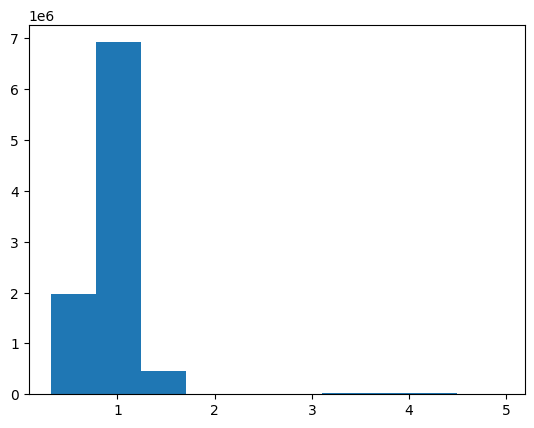

In [6]:
import matplotlib.pyplot as plt
plt.hist(data[:,0])
plt.show()